# ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)

En este cuaderno se realiza un análisis exploratorio de los datos con el objetivo de comprender su estructura, estudiar la distribución de las variables y detectar posibles relaciones entre ellas. Este proceso facilita la comprensión de los datos y ayuda a tomar mejores decisiones de modelado en etapas futuras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Ratings
Contiene las valoraciones emitidas por los usuarios sobre las películas del catálogo junto con una marca temporal.

In [2]:
ratings = pd.read_parquet("../data/02_processed/ratings_integrity.parquet")

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


Tipos de datos

In [4]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100505 entries, 0 to 100504
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userId     100505 non-null  int64         
 1   movieId    100505 non-null  int64         
 2   rating     100505 non-null  float64       
 3   timestamp  100505 non-null  datetime64[ms]
dtypes: datetime64[ms](1), float64(1), int64(2)
memory usage: 3.1 MB


Resumen descriptivo. Se observan los estadísticos principales de userId, movieId, rating y timestamp: la escala de rating va de 0.5 a 5, con una media de 3.5, y las fechas de las valoraciones abarcan desde 1996 hasta 2018.

In [5]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100505.000000,100505.000000,100505.000000,100505
mean,326.121138,19237.089339,3.500826,2008-03-12 07:36:09.693000
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1198.000000,3.000000,2002-03-08 15:28:29
50%,325.000000,2987.000000,3.500000,2007-08-02 19:49:22
75%,477.000000,7749.000000,4.000000,2015-07-04 06:50:44
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.564783,35288.402739,1.042286,NaN


Número de usuarios 

In [6]:
ratings['userId'].nunique()

610

Número de valoraciones por usuario

In [7]:
valoracionesUser = ratings.groupby('userId')['userId'].count().sort_values().reset_index(name='numRatings')
valoracionesUser


,userId,numRatings
0,595,20
1,53,20
2,569,20
3,576,20
4,320,20
...,...,...
605,274,1343
606,448,1861
607,474,2103
608,599,2448


In [8]:
valoracionesUser['numRatings'].describe()

count     610.000000
mean      164.762295
std       268.247167
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2688.000000
Name: numRatings, dtype: float64

Número de usuarios por cada valor de numRatings. Se visualiza la actividad de los usuarios

In [9]:
numUserRating = valoracionesUser.groupby('numRatings')['numRatings'].count().reset_index(name = 'numUser').sort_values('numUser', ascending=False)
numUserRating
    

,numRatings,numUser
1,21,16
2,22,14
0,20,14
6,26,13
3,23,12
...,...,...
236,831,1
237,836,1
238,862,1
239,863,1


In [10]:
numUserRating.describe()

,numRatings,numUser
count,257.000000,257.000000
mean,302.249027,2.373541
std,365.833627,2.563369
min,20.000000,1.000000
25%,85.000000,1.000000
50%,185.000000,1.000000
75%,382.000000,3.000000
max,2688.000000,16.000000


### Número de valoraciones por usuario

El siguiente gráfico de dispersión muestra, para cada número de valoraciones (numRatings), cuántos usuarios tienen exactamente ese número de valoraciones (numUser).

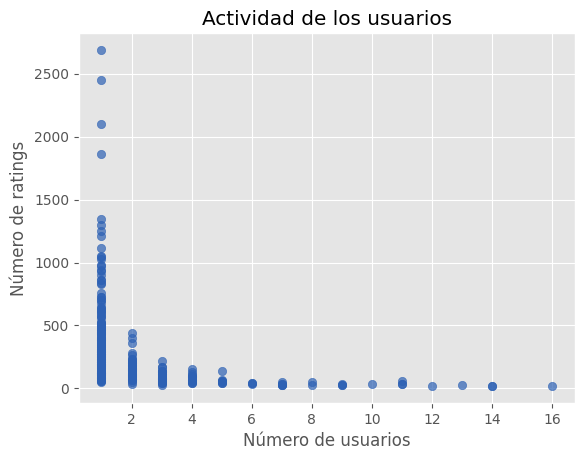

In [11]:
plt.style.use("ggplot")
plt.scatter( numUserRating['numUser'],numUserRating['numRatings'],alpha = 0.7 , color="#2D61B4")
plt.xlabel('Número de usuarios')
plt.ylabel('Número de ratings')
plt.title('Actividad de los usuarios')
plt.show()

Se repite el mismo gráfico con el eje Y en escala logarítmica, ya que el número de valoraciones por usuario varía en un rango muy amplio y en escala lineal apenas se distinguen los valores más bajos.

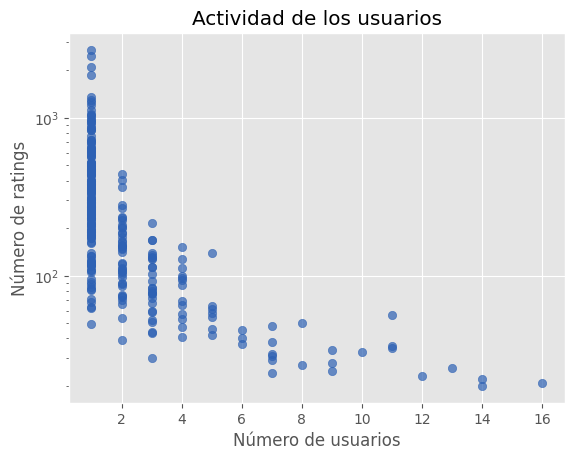

In [12]:
# escala logarítmica:
plt.style.use("ggplot")
plt.scatter( numUserRating['numUser'],numUserRating['numRatings'],alpha = 0.7 , color="#2D61B4")
plt.yscale('log')
# plt.yscale('log')
plt.xlabel('Número de usuarios')
plt.ylabel('Número de ratings')
plt.title('Actividad de los usuarios')
plt.show()

En el análisis de la actividad de los usuarios se observa que la mayoría realiza entre 35 y 168 valoraciones (percentiles 25 y 75), con una media de unas 165 valoraciones por usuario. También hay usuarios con muy pocas valoraciones y usuarios muy activos, con hasta 2688 valoraciones.

Estos casos extremos podrían provocar problemas de cold start en los usuarios con pocas valoraciones, y sesgar el modelo hacia los usuarios más activos.

### Distribución de las valoraciones 
El siguiente histograma muestra como se distribuyen las calificaciones de los usuarios.

In [13]:
ratings['rating'].describe()


count    100505.000000
mean          3.500826
std           1.042286
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [14]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

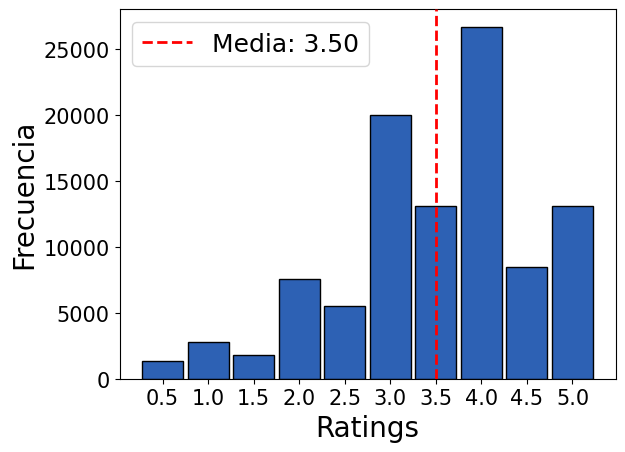

In [15]:
# Distribucion de la variable rating en el dataset ratings. Ratings variable discreta
# plt.style.use("ggplot")
plt.style.use('default')
valores = ratings['rating']
bins = np.arange(0.25,5.75,0.5)
fig, ax = plt.subplots()
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.hist(valores,bins=bins, edgecolor="black", color="#2D61B4", rwidth =0.9, zorder= 2)
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.xlabel('Ratings', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Frecuencia', fontsize=20)
media = valores.mean()
plt.axvline(media, color='red', linestyle='--', linewidth=2, zorder=3, label=f'Media: {media:.2f}')
plt.legend(fontsize=18, facecolor="white")
plt.show()

El histograma muestra que las valoraciones se concentran en los valores centrales y altos de la escala, con 4.0 como valor más frecuente (moda) y una media de 3.5. Hay muy pocas valoraciones en el extremo inferior de la escala.

### Número de valoraciones por usuario, agrupado por rangos

Se agrupan los usuarios en rangos de número de valoraciones para visualizar su distribución con un gráfico de barras, complementario al gráfico de dispersión anterior.

In [16]:
numUserRating['numUser']

1      16
2      14
0      14
6      13
3      12
       ..
236     1
237     1
238     1
239     1
256     1
Name: numUser, Length: 257, dtype: int64

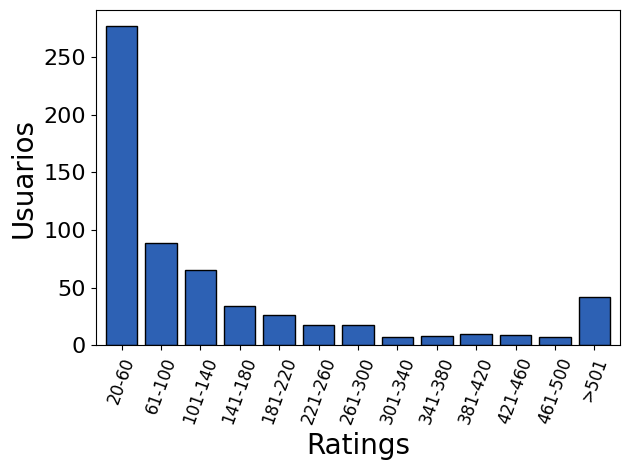

In [17]:
# plt.style.use("ggplot")
bins = [20,  60, 100, 140,180, 220, 260,300,340,380,420,460,500, float("inf")]
labels = ["20-60", "61-100", "101-140", "141-180", "181-220", "221-260", "261-300", "301-340", "341-380","381-420", "421-460", "461-500", ">501"]

grupos = pd.cut(valoracionesUser['numRatings'], bins=bins, labels=labels, include_lowest=True)
conteo = grupos.value_counts().reindex(labels)

fig, ax = plt.subplots()
conteo.plot.bar(ax=ax, edgecolor="black", color="#2D61B4", zorder=2, width=0.8)

plt.xlabel("Ratings", fontsize=20)
plt.ylabel("Usuarios", fontsize=20)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.xticks(fontsize=12,rotation=70,ha='center')
plt.yticks(fontsize=16)
plt.tight_layout()
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.show()

### Número de valoraciones por película

In [18]:
numValPel = ratings.groupby('movieId')['movieId'].count()
numValPel.describe()

count    9598.000000
mean       10.471452
std        22.525259
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: movieId, dtype: float64

La media de valoraciones por película (10.47) es bastante mayor que la mediana (3), lo que indica una distribución muy asimétrica: la mayoría de las películas tienen pocas valoraciones, mientras que unas pocas concentran muchas (hasta 329). Esta desigualdad es relevante de cara al filtrado colaborativo, ya que las películas con pocas valoraciones son más difíciles de recomendar de forma fiable.

In [19]:
numValPel.sort_values(ascending=True)

movieId
190221      1
190219      1
49          1
190215      1
188675      1
         ... 
2571      278
593       279
296       307
318       317
356       329
Name: movieId, Length: 9598, dtype: int64

Se agrupan las películas en rangos según su número de valoraciones, para visualizar mejor esta distribución con un gráfico de barras.

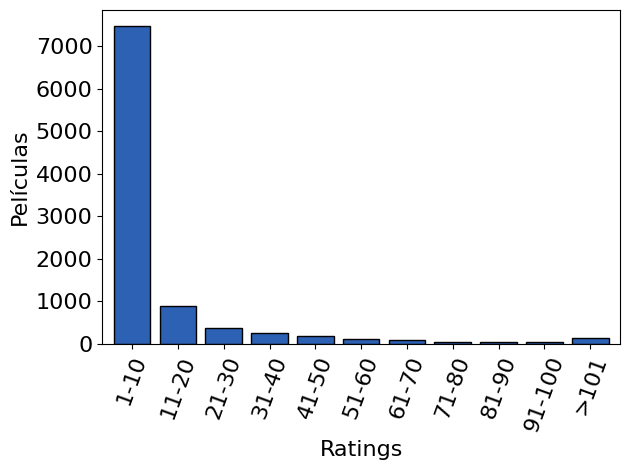

In [20]:

bins = [0, 10,  20, 30,40,50,60,70,80,90,100, float("inf")]
labels = ["1-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90","91-100",">101"]

grupos = pd.cut(numValPel, bins=bins, labels=labels, include_lowest=True)
conteo = grupos.value_counts().reindex(labels)

fig, ax = plt.subplots()
conteo.plot.bar(ax=ax, edgecolor="black", color="#2D61B4", zorder=2, width=0.8)   
plt.style.use("ggplot")

plt.xlabel("Ratings",fontsize=16)
plt.ylabel("Películas",fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax.set_xticklabels(labels, rotation=70, ha="center")
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

## Dataset TMDB

In [21]:
TMDB = pd.read_parquet("../data/02_processed/TMDB_integrity.parquet")
TMDB

,id,title,genres,popularity,overview,tagline,vote_average,vote_count,runtime,budget,revenue,release_date
0,2,Ariel,"[Comedy, Drama, Romance, Crime]",1.3807,A Finnish man goes to the city to find a job a...,,7.121,375,73,0,0,1988-10-21
1,5,Four Rooms,[Comedy],3.6807,It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...,5.904,2847,98,4000000,4257354,1995-12-09
2,6,Judgment Night,"[Action, Crime, Thriller]",1.8049,"Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.,6.463,377,109,21000000,12136938,1993-10-15
3,11,Star Wars,"[Adventure, Action, Science Fiction]",27.0355,Princess Leia is captured and held hostage by ...,"A long time ago in a galaxy far, far away...",8.205,22361,121,11000000,775398007,1977-05-25
4,12,Finding Nemo,"[Animation, Family, Adventure]",19.5501,"Nemo, an adventurous young clownfish, is unexp...",There are 3.7 trillion fish in the ocean. They...,7.819,20567,100,94000000,940335536,2003-05-30
...,...,...,...,...,...,...,...,...,...,...,...,...
9610,497520,Tom Segura: Disgraceful,[Comedy],0.2180,Tom Segura gives voice to the sordid thoughts ...,,7.100,81,74,0,0,2018-01-12
9611,500475,SuperFly,"[Action, Crime]",2.7139,Career criminal Youngblood Priest wants out of...,Redefine the hussle,6.706,406,107,16000000,20545116,2018-06-13
9612,502616,Fred Armisen: Standup for Drummers,"[Music, Comedy]",0.2086,"For an audience of drummers, comedian Fred Arm...","I don't want to work, I just want to bang on t...",6.300,33,65,0,0,2018-02-06
9613,503475,Wallace & Gromit: The Best of Aardman Animation,"[Family, Animation, Comedy]",0.6346,Anthology of Aardman Animation short films rel...,The Best of Aardman Animation,7.600,5,75,0,0,1996-06-14


Para elaborar un gráfico de sectores con los géneros, primero se separa la lista de géneros de cada película (`explode`) y luego se agrupan para contar cuántas películas hay de cada género.

In [23]:
generos = TMDB.explode('genres').groupby('genres')['genres'].count()
generos

genres
Action             1898
Adventure          1373
Animation           598
Comedy             3934
Crime              1494
Documentary         414
Drama              4526
Family              909
Fantasy             901
History             458
Horror             1024
Music               363
Mystery             710
Romance            1974
Science Fiction    1059
TV Movie            163
Thriller           1986
War                 340
Western             176
Name: genres, dtype: int64

### Gráfico de sectores géneros (TMDB)

In [24]:
generos

genres
Action             1898
Adventure          1373
Animation           598
Comedy             3934
Crime              1494
Documentary         414
Drama              4526
Family              909
Fantasy             901
History             458
Horror             1024
Music               363
Mystery             710
Romance            1974
Science Fiction    1059
TV Movie            163
Thriller           1986
War                 340
Western             176
Name: genres, dtype: int64

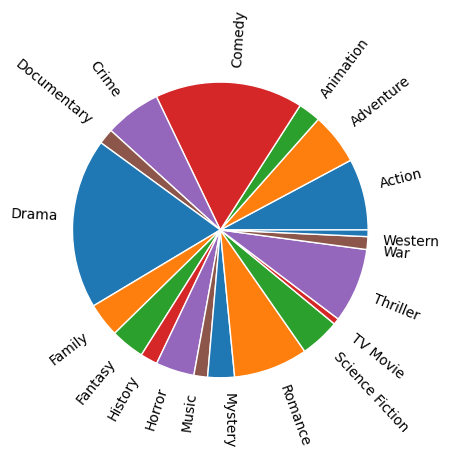

In [25]:
#grafico sectores TMDB
generos = TMDB.explode('genres').sort_values('genres').groupby('genres')['genres'].count()

grupos = generos.index
valor = generos.values
plt.style.use("ggplot")
fig, ax = plt.subplots()
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
ax.pie(valor, labels = grupos, rotatelabels = True, wedgeprops = {"linewidth": 1, "edgecolor": "white"},colors = colores)
plt.show()

### Gráfico de barras géneros (TMDB)

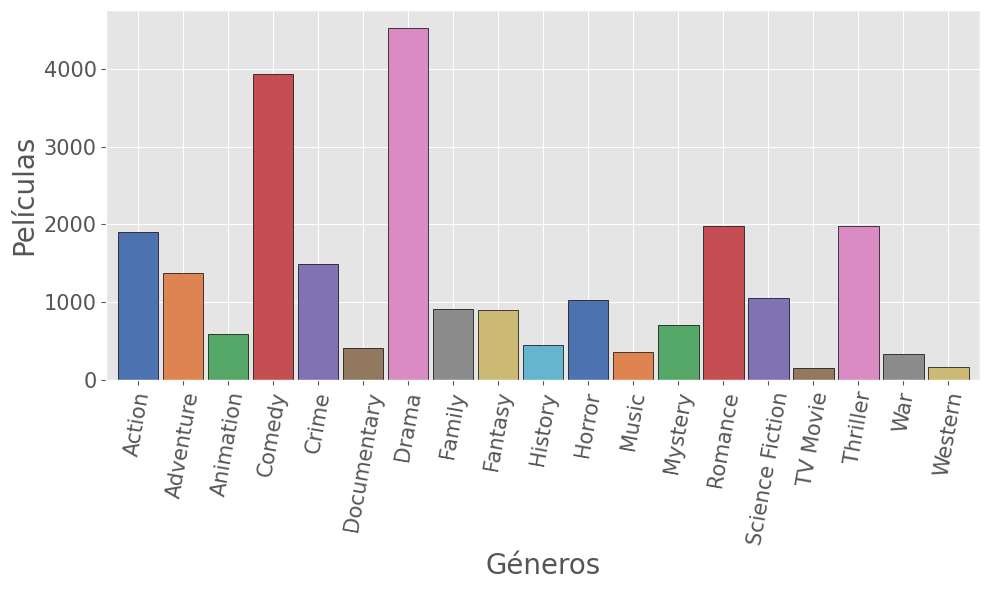

In [26]:
# plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("deep", len(generos))
generos.plot.bar(ax=ax, edgecolor="black", color=colores, zorder=2, width=0.9)   

plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Películas", fontsize=20)
ax.set_xticklabels(generos.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

La misma información se representa como gráfico de barras, más fácil de leer que el de sectores cuando hay muchas categorías. Se observa que Drama y Comedy son, con diferencia, los géneros más frecuentes en TMDB, mientras que TV Movie y Western son los menos frecuentes.

In [ ]:
# mismos graficos pero desde movies
movies = pd.read_parquet("../data/02_processed/movies_integrity.parquet")
movies['genres'] = movies['genres'].str.split('|') 
generos2 = movies.explode('genres').sort_values('genres').groupby('genres')['genres'].size()
generos2

### Gráfico de sectores géneros (MovieLens)

## Comparación con los géneros de movies (MovieLens)

Se repite el mismo análisis de géneros a partir de movies.parquet, cuya columna genres procede directamente de MovieLens en lugar de TMDB. Conviene tener en cuenta que ambas fuentes usan taxonomías de género distintas: por ejemplo, MovieLens incluye categorías como Sci-Fi, Children, Musical, Film-Noir o IMAX que no existen en TMDB, mientras que TMDB usa nombres como Science Fiction, Family, Music, History o TV Movie. Por eso los resultados de ambos análisis no son directamente comparables género a género.

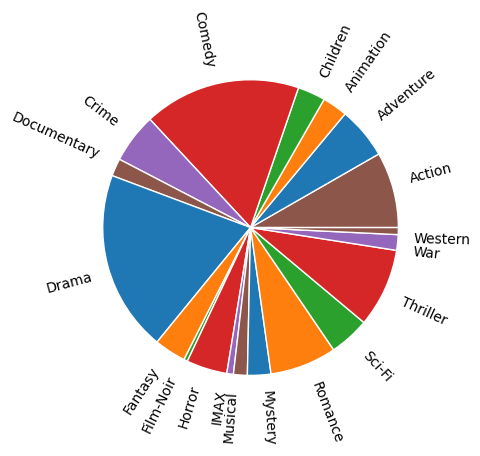

In [28]:
#grafico sectores géneros MOVIES
grupos2 = generos2.index
valor2 = generos2.values

fig, ax = plt.subplots()
colores = [ "#8c564b" ,"#1f77b4","#ff7f0e","#2ca02c","#d62728", "#9467bd"]
ax.pie(valor2, labels = grupos2, rotatelabels = True,  wedgeprops = {"linewidth": 1, "edgecolor": "white"}, colors=colores)
plt.show() 


### Gráfico de barras géneros (MovieLens)

Al igual que en TMDB, Drama y Comedy son los géneros predominantes en MovieLens, lo que confirma que la distribución de géneros está desequilibrada independientemente de la fuente de datos.

In [29]:
plt.style.use("default")

In [30]:
generos2

genres
Action         1804
Adventure      1233
Animation       599
Children        660
Comedy         3737
Crime          1184
Documentary     419
Drama          4310
Fantasy         756
Film-Noir        87
Horror          969
IMAX            157
Musical         328
Mystery         557
Romance        1585
Sci-Fi          958
Thriller       1876
War             372
Western         166
Name: genres, dtype: int64

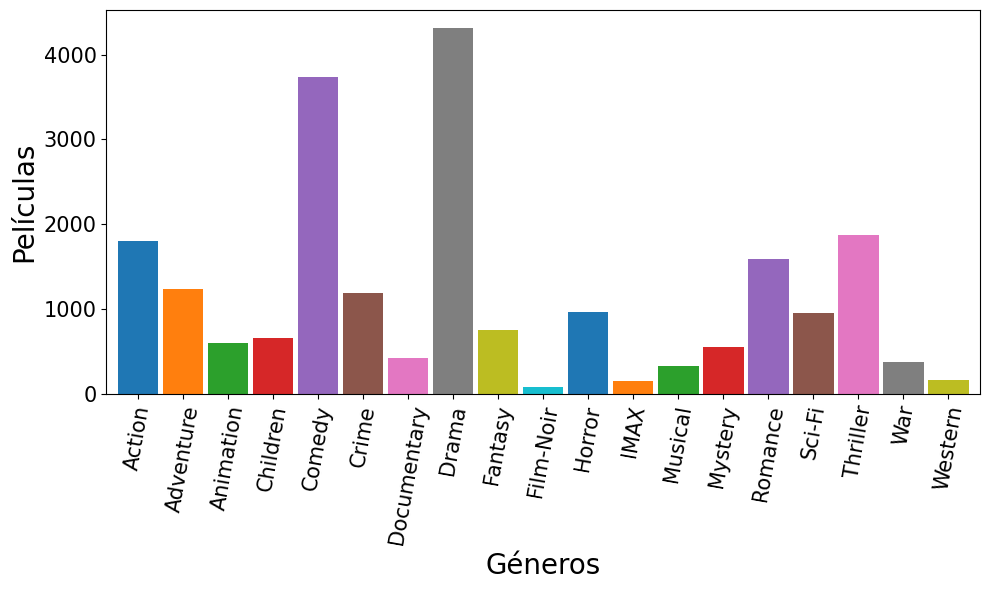

In [31]:

# plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
generos2.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   

plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Películas", fontsize=20)
ax.set_xticklabels(generos2.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

In [32]:
media

np.float64(3.500825829560718)

Se recupera `media`, la media global de las valoraciones calculada anteriormente para el histograma, que se usará como referencia al comparar la media de valoraciones por género.

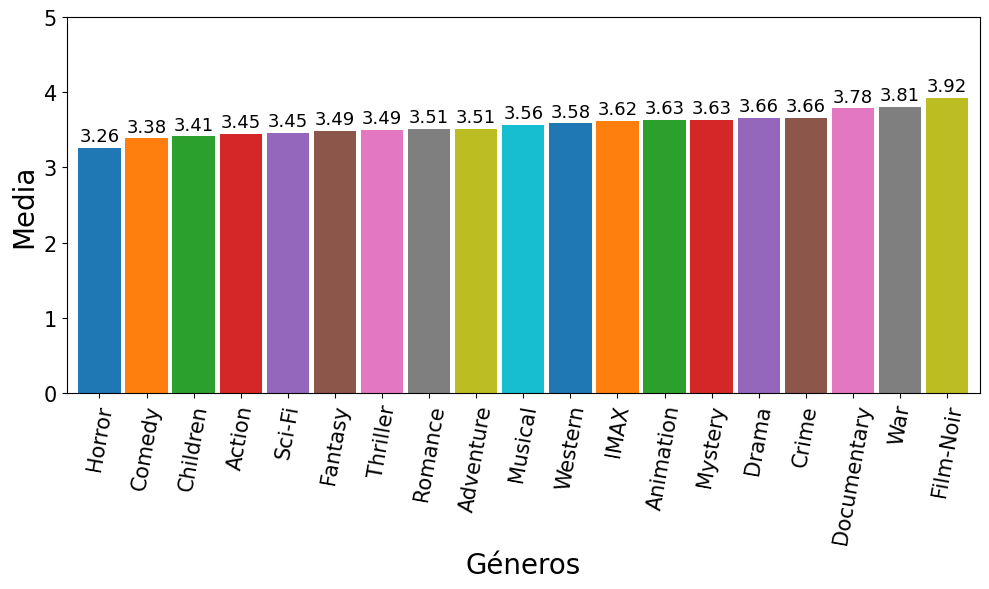

In [33]:
# media de ratings por generos
datos = pd.merge(movies.explode('genres'), ratings, on="movieId")
media = datos.groupby('genres')['rating'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
media.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=13)
plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Media", fontsize=20)
ax.set_ylim(0, 5)
ax.set_xticklabels(media.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

### Media de valoraciones por género

Se cruzan movies (con los géneros separados) y ratings por movieId, para calcular la media de rating de cada género y compararla con la media global.

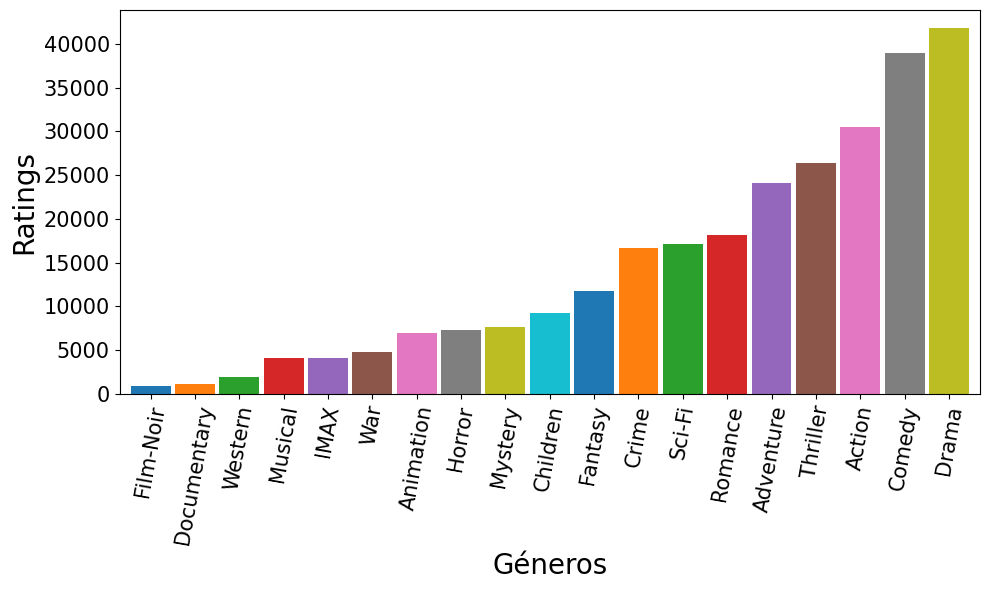

In [34]:
#numero de ratings por cada genero
datos = pd.merge(movies.explode('genres'), ratings, on="movieId")
cuenta = datos.groupby('genres')['rating'].count().sort_values()
cuenta
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
cuenta.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   
plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Ratings", fontsize=20)
ax.set_xticklabels(cuenta.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

### Número de valoraciones por género

Se cuenta cuántas valoraciones tiene cada género, como complemento al gráfico anterior: una media alta o baja es más fiable cuanto mayor sea el número de valoraciones en las que se basa.

In [35]:
generos.index

Index(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery',
       'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
      dtype='str', name='genres')

Lista de los géneros de TMDB, usada como referencia rápida para comprobar los nombres exactos empleados en los gráficos anteriores.

### Evolución temporal de las valoraciones

Se extrae el año de cada valoración a partir de timestamp, para estudiar cómo evoluciona el número de valoraciones a lo largo del tiempo.

In [36]:
ratings['timestamp'] = ratings['timestamp'].dt.year


In [37]:
peliculasAnios = ratings.groupby('timestamp').size()

In [38]:
peliculasAnios

timestamp
1996     6040
1997     1915
1998      507
1999     2437
2000    10058
2001     3919
2002     3476
2003     4012
2004     3276
2005     5812
2006     4055
2007     7106
2008     4341
2009     4133
2010     2283
2011     1682
2012     4639
2013     1659
2014     1428
2015     6572
2016     6673
2017     8149
2018     6333
dtype: int64

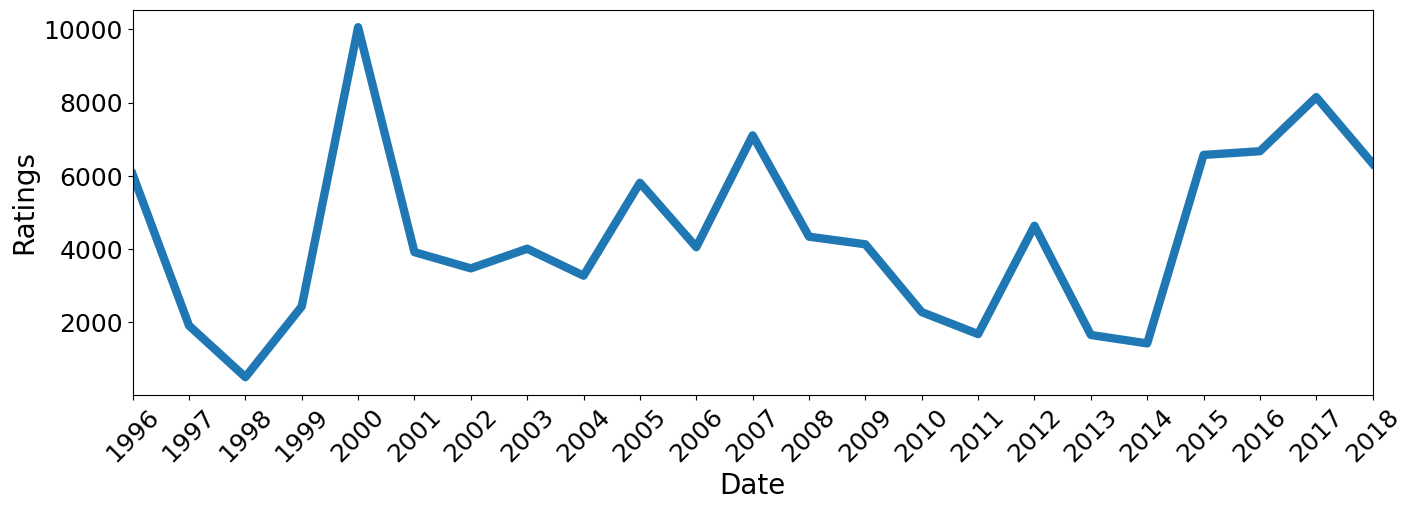

In [39]:
fig = plt.subplots(figsize=(16, 5))
plt.plot(peliculasAnios.index, peliculasAnios.values,linewidth=6)

plt.xlabel('Date', fontsize=20)
plt.ylabel('Ratings', fontsize=20)
plt.xlim(peliculasAnios.index.min(), peliculasAnios.index.max())

ticks = list(peliculasAnios.index)
plt.yticks(fontsize=18)
plt.xticks(ticks, rotation=45, fontsize=18)
plt.show()

El número de valoraciones por año no sigue una tendencia uniforme, sino que presenta picos notables (por ejemplo en 2000 y 2007) y años con muy pocas valoraciones (como 1998), probablemente asociados a ampliaciones puntuales del propio dataset de MovieLens más que a un cambio real en el comportamiento de los usuarios.

## Análisis de las dificultades

Se estudia la dispersión (sparsity) de la matriz usuario-película, uno de los principales retos del filtrado colaborativo: cuanto más dispersa es la matriz, más difícil resulta encontrar patrones de similitud fiables entre usuarios o películas.

In [40]:
# Número de ratings
nRatings = len(ratings)
nRatings

100505

In [41]:
# matriz de dispersión
nUsuarios = ratings['userId'].nunique()
nPeliculas = movies['movieId'].nunique()

#celdas posibles vs reales
celdas_posibles = nUsuarios * nPeliculas
celdas_reales = len(ratings)

# Densidad y dispersion
densidad = celdas_reales / celdas_posibles
dispersion = 1 - densidad

#resultados
print(f"Usuarios: {nUsuarios}")
print(f"Películas: {nPeliculas}")
print(f"Celdas posibles: {celdas_posibles}")
print(f"Ratings reales: {celdas_reales}")
print(f"Densidad: {densidad:.4}")
print(f"Dispersidad: {dispersion:.4}")

Usuarios: 610
Películas: 9616
Celdas posibles: 5865760
Ratings reales: 100505
Densidad: 0.01713
Dispersidad: 0.9829


La matriz usuario-película tiene una densidad de apenas un 1.7%, es decir, una dispersión del 98.3%: de las cerca de 5.9 millones de combinaciones posibles entre los 610 usuarios y las 9616 películas, solo existen unas 100.500 valoraciones reales. Esta alta dispersión, junto con la desigual actividad de usuarios y películas observada anteriormente, son los principales retos a tener en cuenta al diseñar el sistema de recomendación.